# Exploration approfondie de la base d'apprentissage

In [1]:
import pandas as pd
import sys
import os
import warnings
import pingouin as pg

warnings.filterwarnings("ignore")

# On connecte le notebook à tous les fichiers inclus dans le dossier /fonctions
sys.path.insert(0, os.path.abspath("../fonctions"))

%load_ext autoreload
%autoreload 

from eda import *

In [2]:
# Configuration
FILE_PATH = "../data_finale/val.csv"
TARGET    = "market_value_in_eur"
dossier_sauvegarde = "../outputs/eda"

In [3]:
# Chargement de la base de données

df_base = pd.read_csv(FILE_PATH)

In [4]:
print("Types des variables")

analyser_types(df_base)

Types des variables
Analyse des types de variables
Variables numériques   : 150
Variables catégorielles: 4


Analyse des valeurs manquantes
                      nb_missing    pct
xa                           834  34.31
xg_buildup                   834  34.31
xg_buildup_nor               834  34.31
xa_nor                       834  34.31
Subs_Mn/Sub_nor              312  12.83
Subs_Mn/Sub                  312  12.83
Team Success_On-Off           19   0.78
Team Success_PPM               3   0.12
Team Success_PPM_nor           3   0.12
height_in_cm                   2   0.08



Graphique sauvegardé sous : ..\outputs\eda\valeurs_manquantes.png


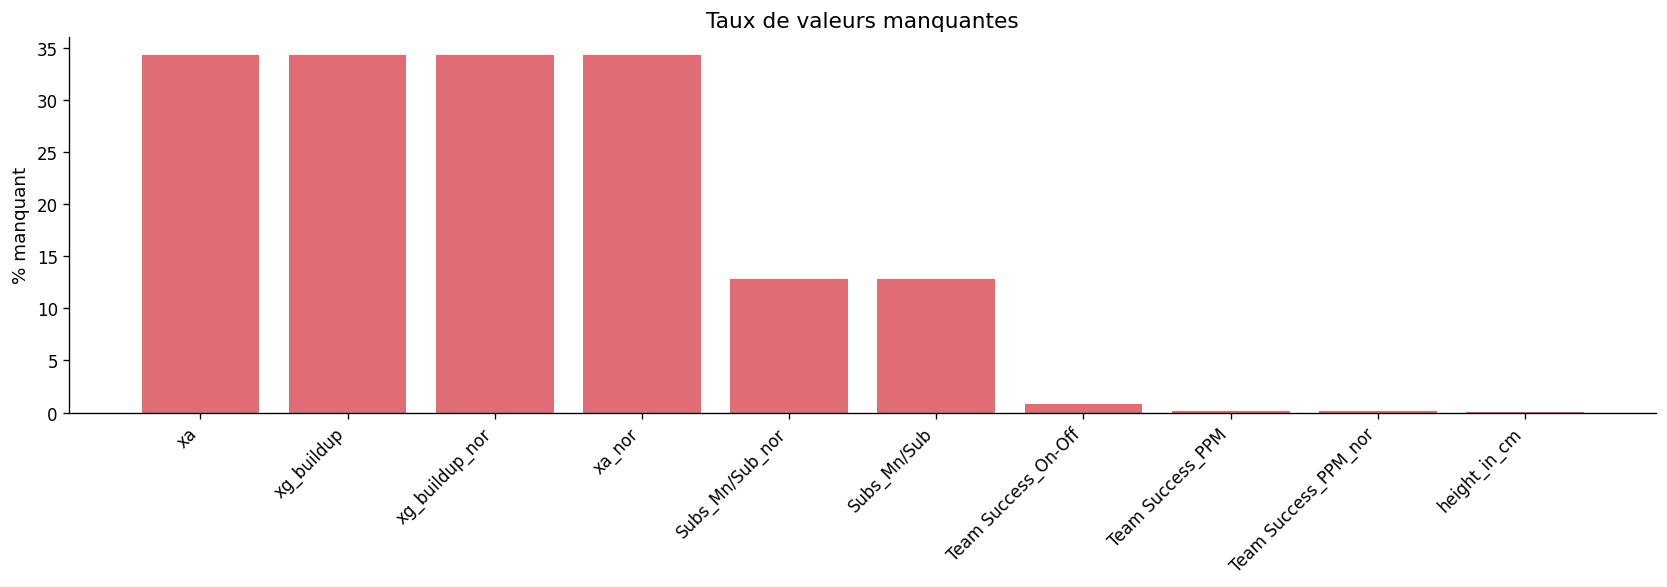

In [5]:
analyser_valeurs_manquantes(df_base, dossier_sauvegarde=dossier_sauvegarde)

Analyse de la variable cible : market_value_in_eur
count          2,431
mean      12,006,643
std       18,000,647
min           50,000
25%        2,000,000
50%        5,000,000
75%       15,000,000
max      180,000,000
Name: market_value_in_eur, dtype: str

Skewness : 3.78
Kurtosis : 21.46



Graphique sauvegardé sous : ..\outputs\eda\distribution_market_value_in_eur.png


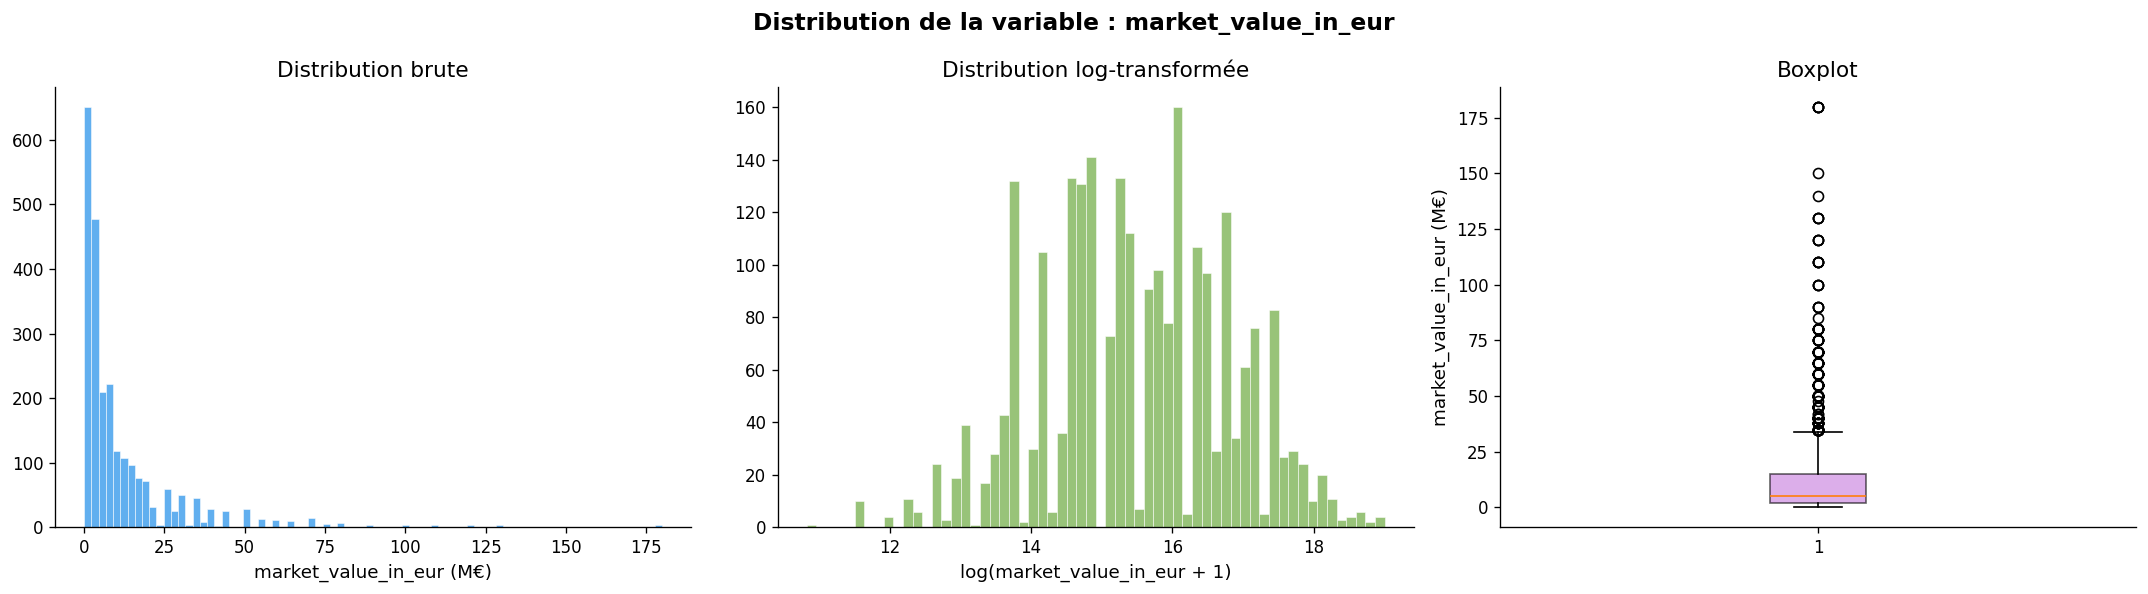

In [6]:
analyser_variable_cible(df_base, target_col=TARGET, dossier_sauvegarde=dossier_sauvegarde)

Distributions des variables numériques clés

Graphique sauvegardé sous : ..\outputs\eda\distributions_variables_numeriques_cles.png


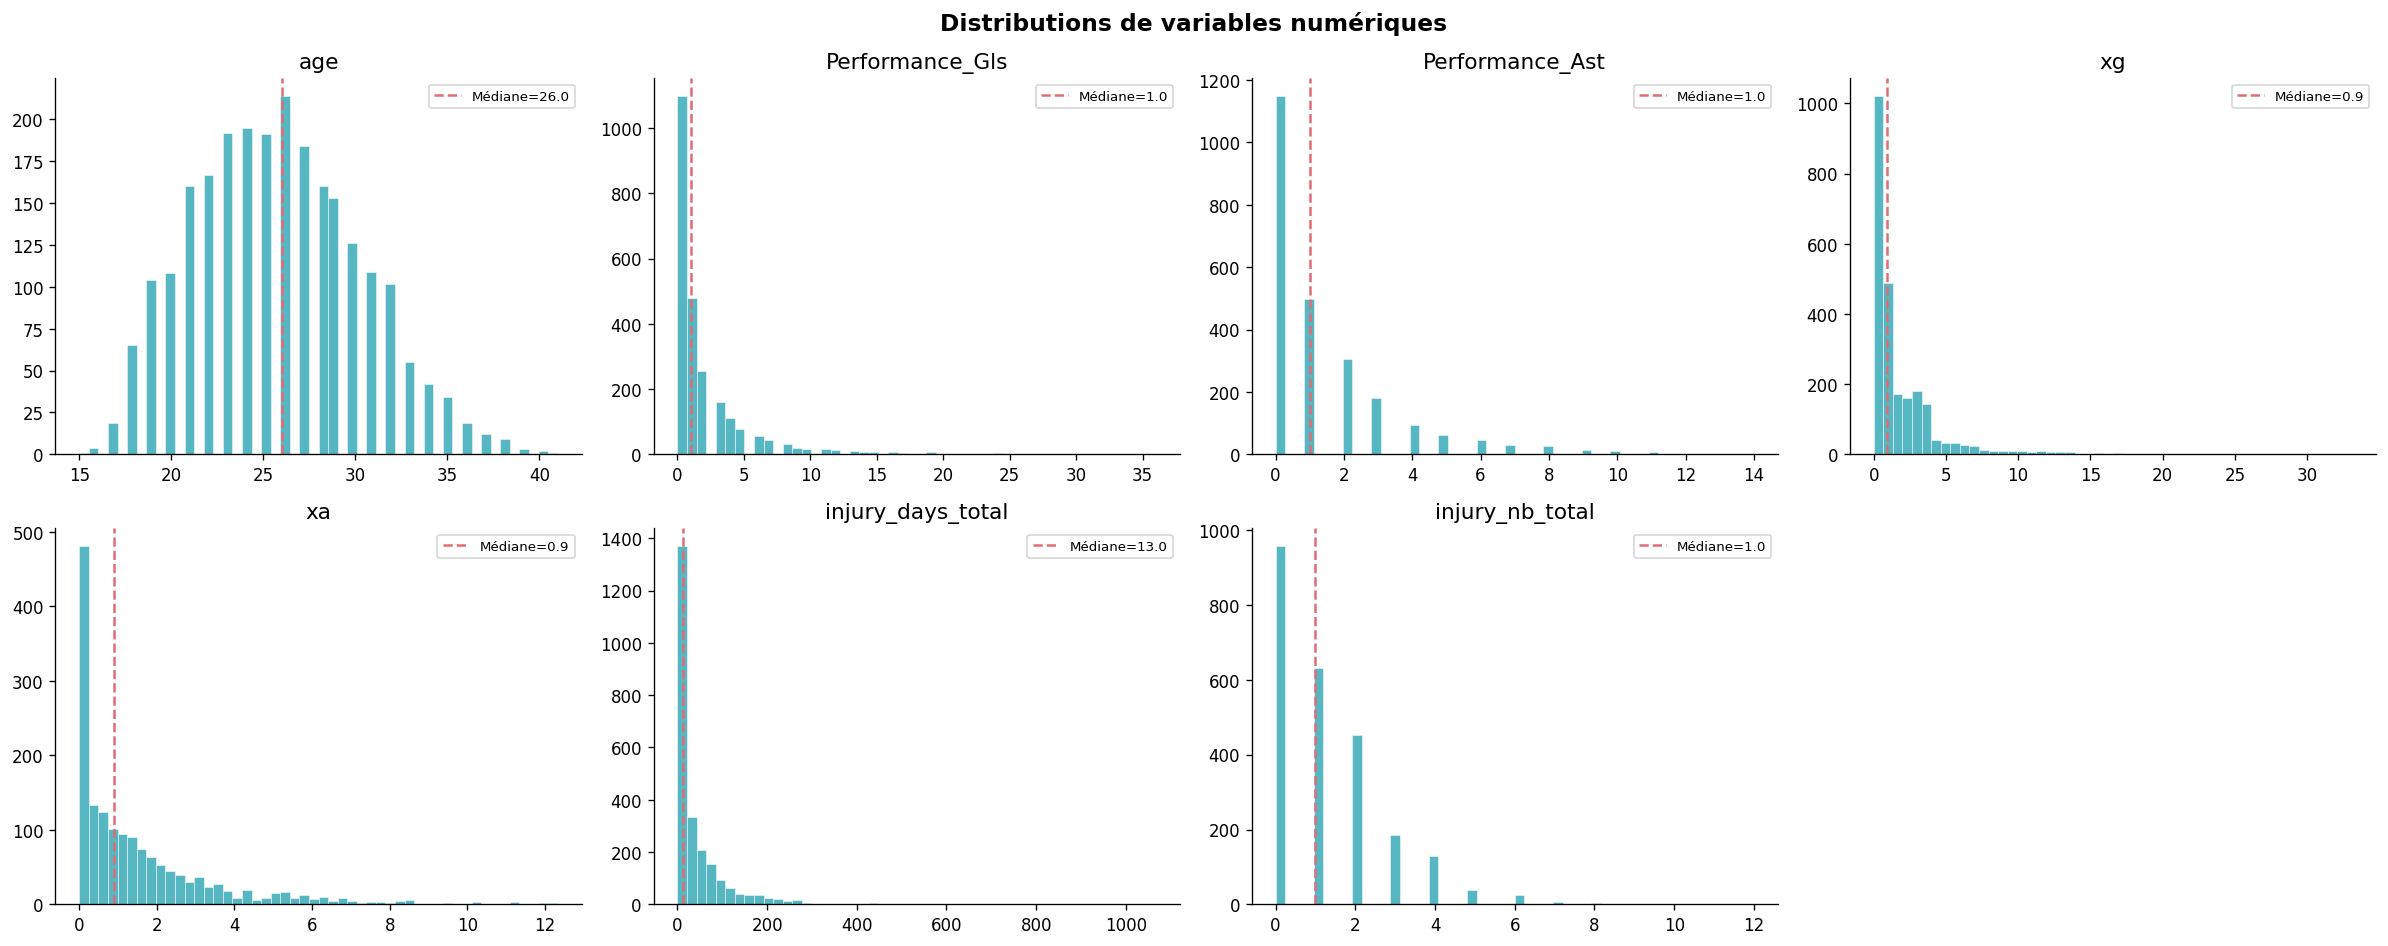

In [7]:
analyser_distributions_numeriques(df_base, cols_a_analyser=None, dossier_sauvegarde=dossier_sauvegarde)

Analyse des variables catégorielles

league (5 modalités encodées) :
ITA-Serie A           525
ESP-La Liga           514
ENG-Premier League    491
FRA-Ligue 1           453
GER-Bundesliga        448

players_top_nations.png sauvegardé


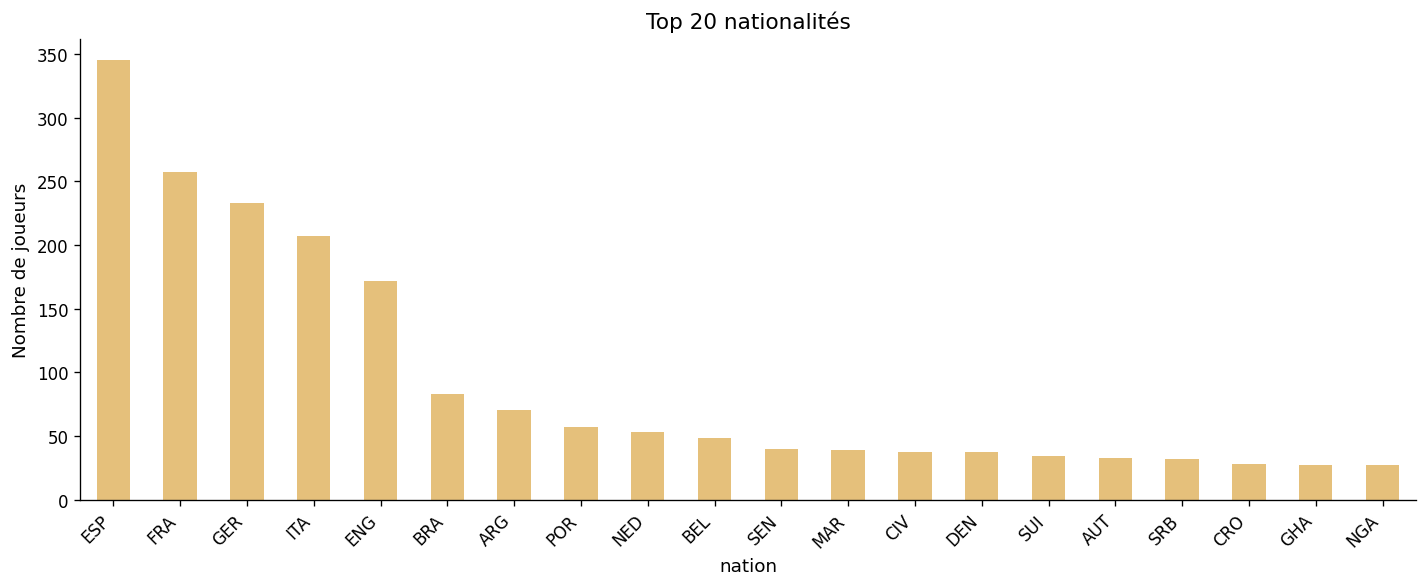

league.png sauvegardé


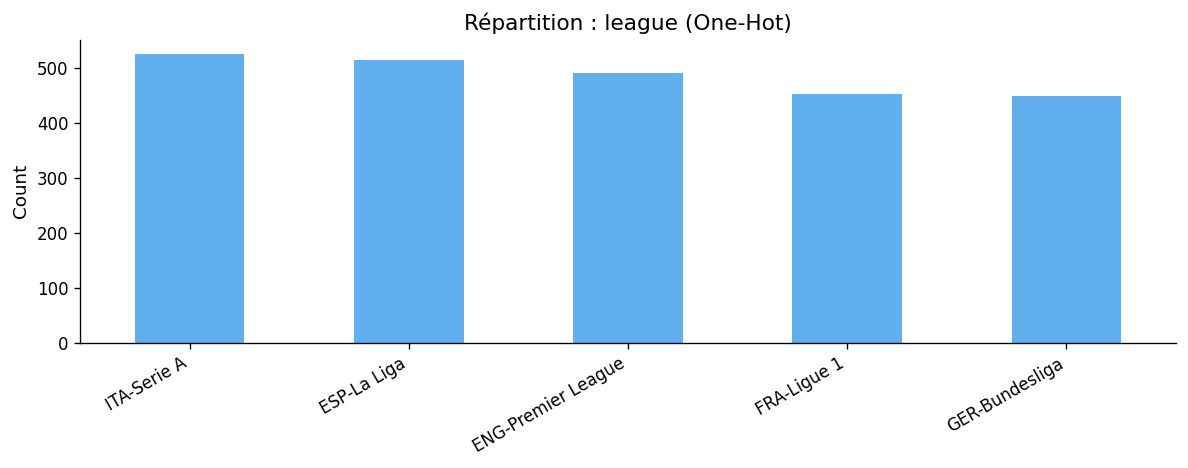

vm_par_league.png sauvegardé


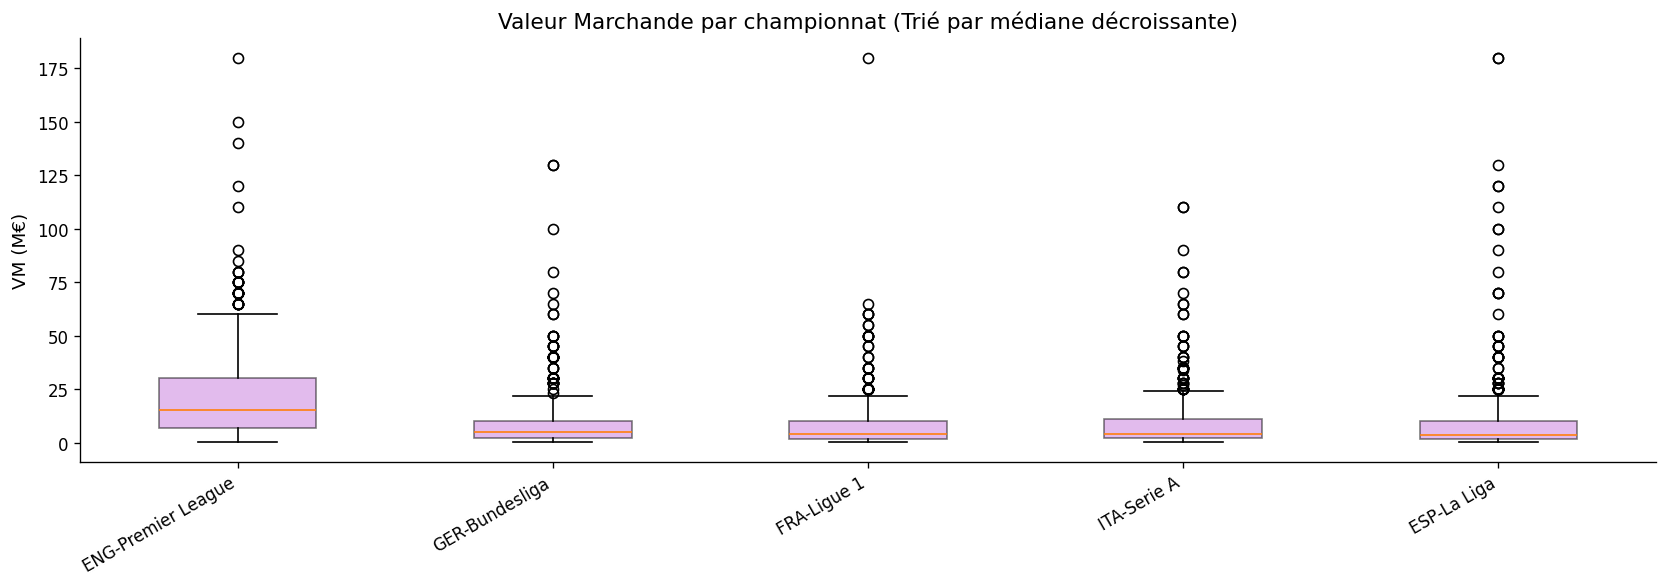

In [8]:
analyser_variables_categorielles(df_base, TARGET, dossier_sauvegarde=dossier_sauvegarde)

In [9]:
analyser_outliers(df_base)

Détection des outliers
         variable  outliers_IQR  pct_IQR  outliers_Zscore  total
              age             3      0.1                3   2431
  Performance_Gls           250     10.3               53   2431
  Performance_Ast           141      5.8               64   2431
               xg           170      7.0               59   2431
               xa           106      6.6               34   1597
injury_days_total           194      8.0               46   2431
  injury_nb_total            36      1.5               36   2431


Analyse des corrélations (cible : market_value_in_eur)

Corrélation linéaire avec la cible (variables clés)
                     market_value_in_eur
market_value_in_eur             1.000000
Performance_Gls                 0.508314
xa                              0.474572
Performance_Ast                 0.461852
xg                              0.379244
injury_nb_total                 0.152877
injury_days_total               0.055017
age                            -0.174519

matrice_correlation.png sauvegardé sous : ..\outputs\eda\matrice_correlation.png


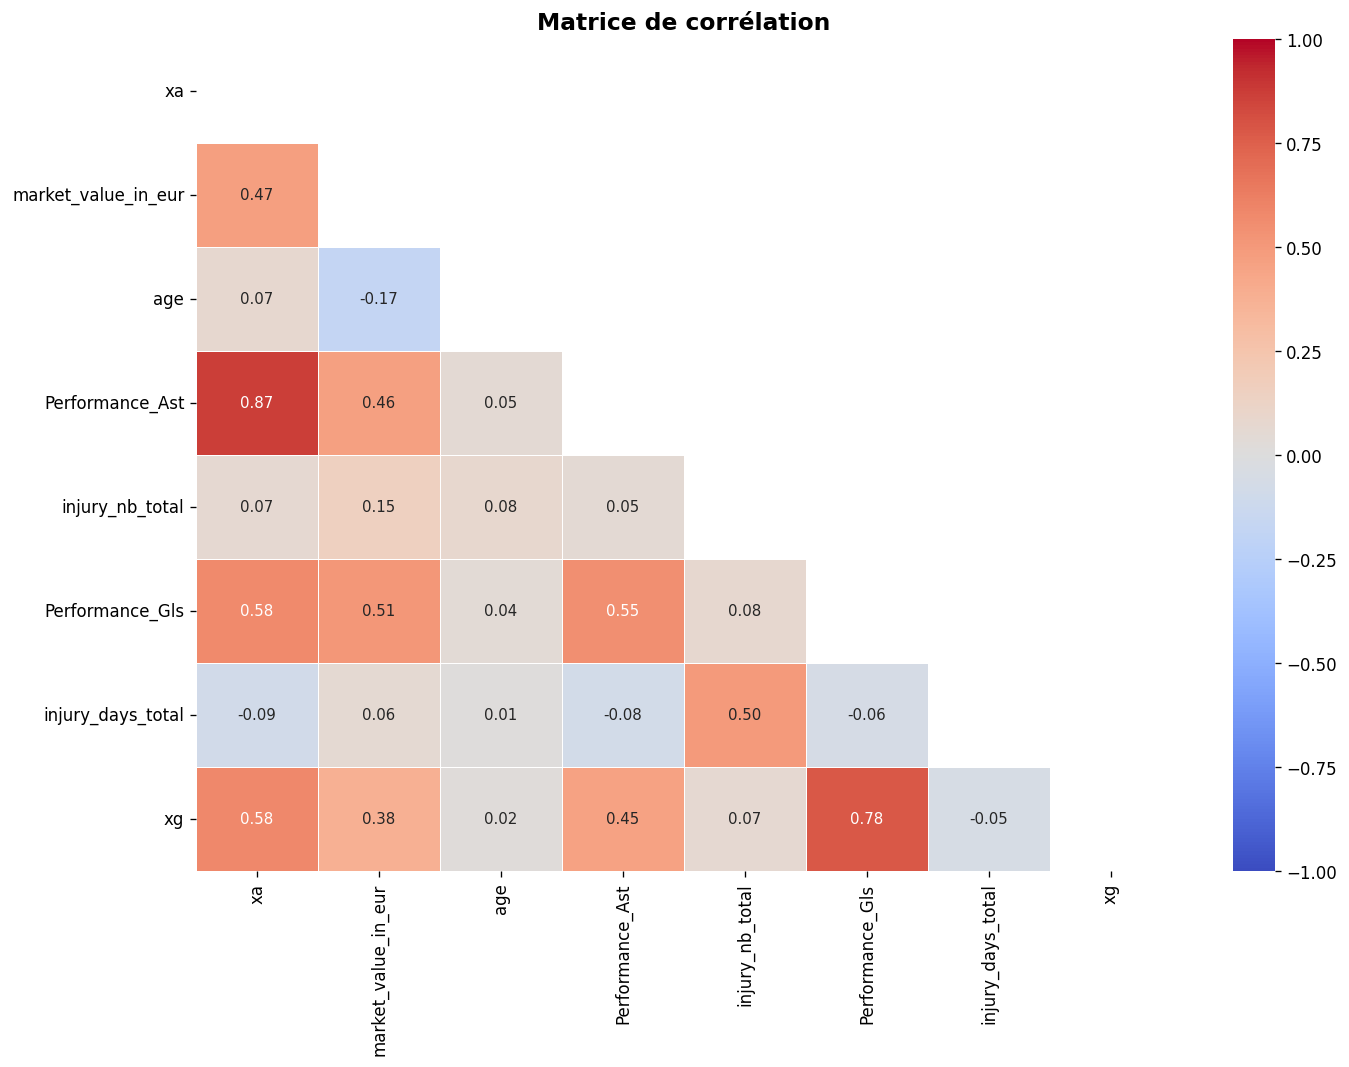


Top 20 des corrélations absolues avec market_value_in_eur (Toutes variables numériques)
market_value_in_eur_nor    1.000000
Team Success_onG           0.576328
xg_buildup_nor             0.540989
xg_buildup                 0.540989
Performance_G-PK           0.511288
Performance_Gls_nor        0.508314
Performance_Gls            0.508314
Standard_SoT               0.504708
Standard_SoT_nor           0.504708
Standard_Sh_nor            0.496690
Standard_Sh                0.496690
xa_nor                     0.474572
xa                         0.474572
Performance_Ast_nor        0.461852
Performance_Ast            0.461852
xg_nor                     0.379244
xg                         0.379244
classement                 0.374305
Performance_Fld            0.359035
Playing Time_Starts_nor    0.356004


In [10]:
analyser_correlations(df_base, TARGET, cols_cles=None, dossier_sauvegarde=dossier_sauvegarde)

## Segmentation par poste

Analyse du profil médian par poste



Graphique sauvegardé sous : ..\outputs\eda\segmentation_par_poste_profil_poste.png


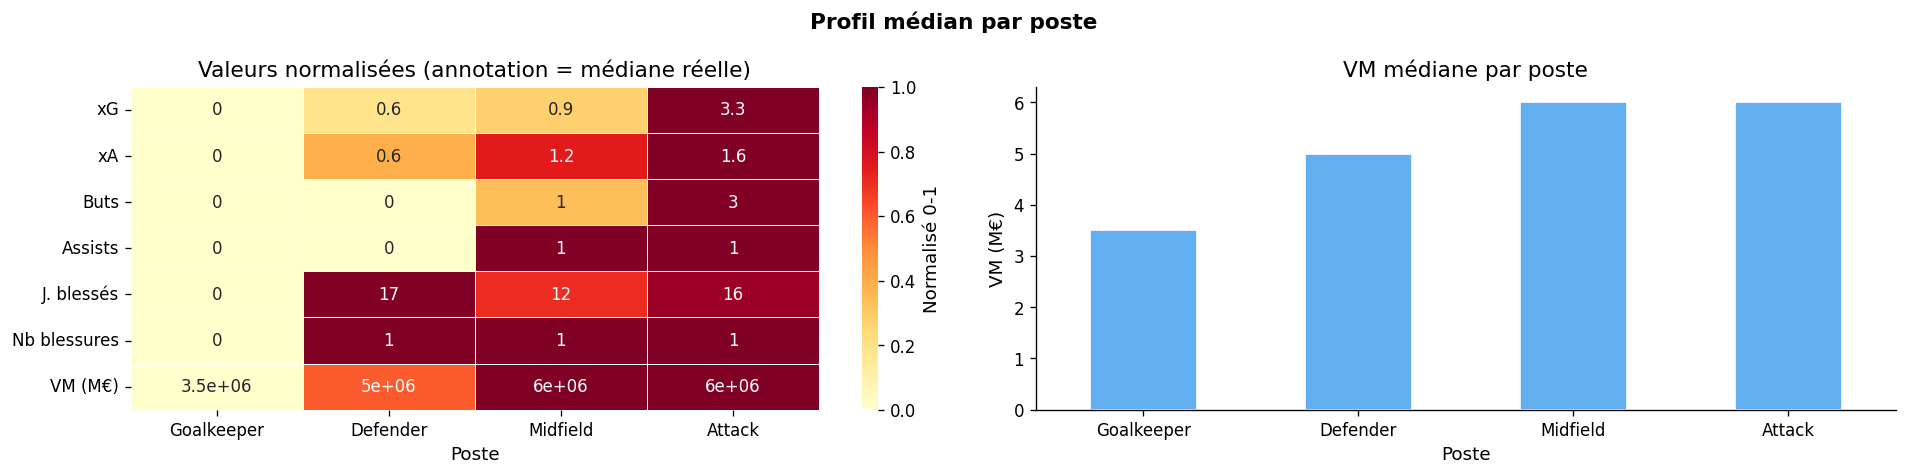

In [11]:
analyser_profil_par_poste(df_base, TARGET, dossier_sauvegarde=dossier_sauvegarde, couleurs_dict=None)

Analyse de la distribution des âges par poste
Graphique sauvegardé sous : ..\outputs\eda\segmentation_par_poste_age_par_poste.png


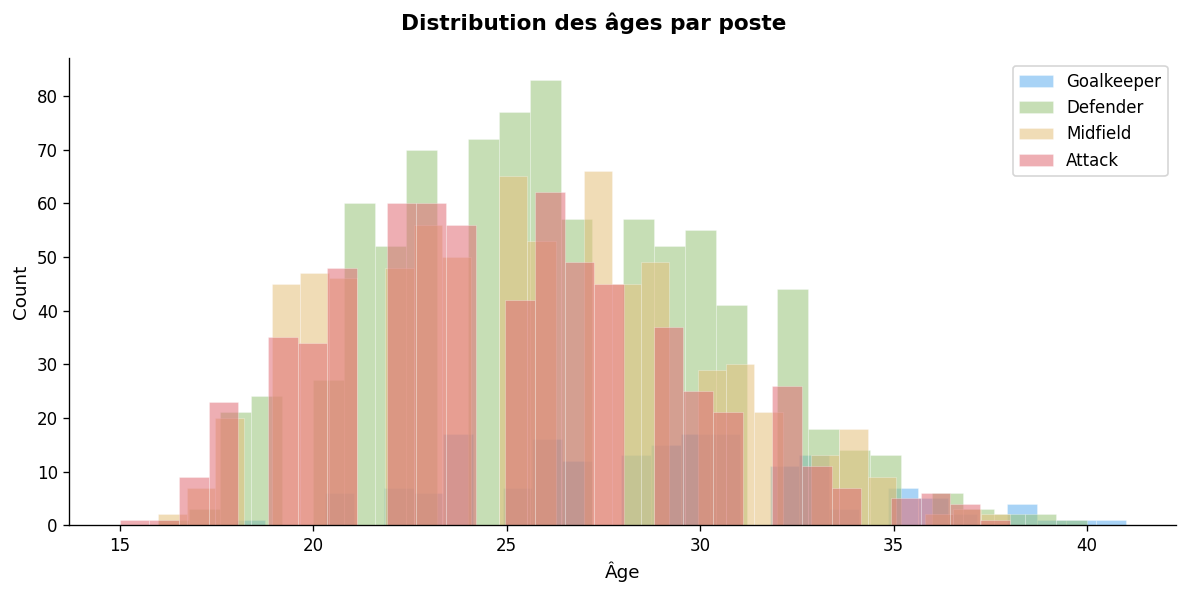


Âge médian par poste
position
Goalkeeper    29.0
Defender      26.0
Midfield      25.0
Attack        25.0


In [12]:
analyser_ages_par_poste(df_base, dossier_sauvegarde=dossier_sauvegarde, liste_couleurs=None)

Analyse croisée : VM médiane par championnat et par poste



Heatmap sauvegardée sous : ..\outputs\eda\feature_engineered_heatmap_league_pos.png


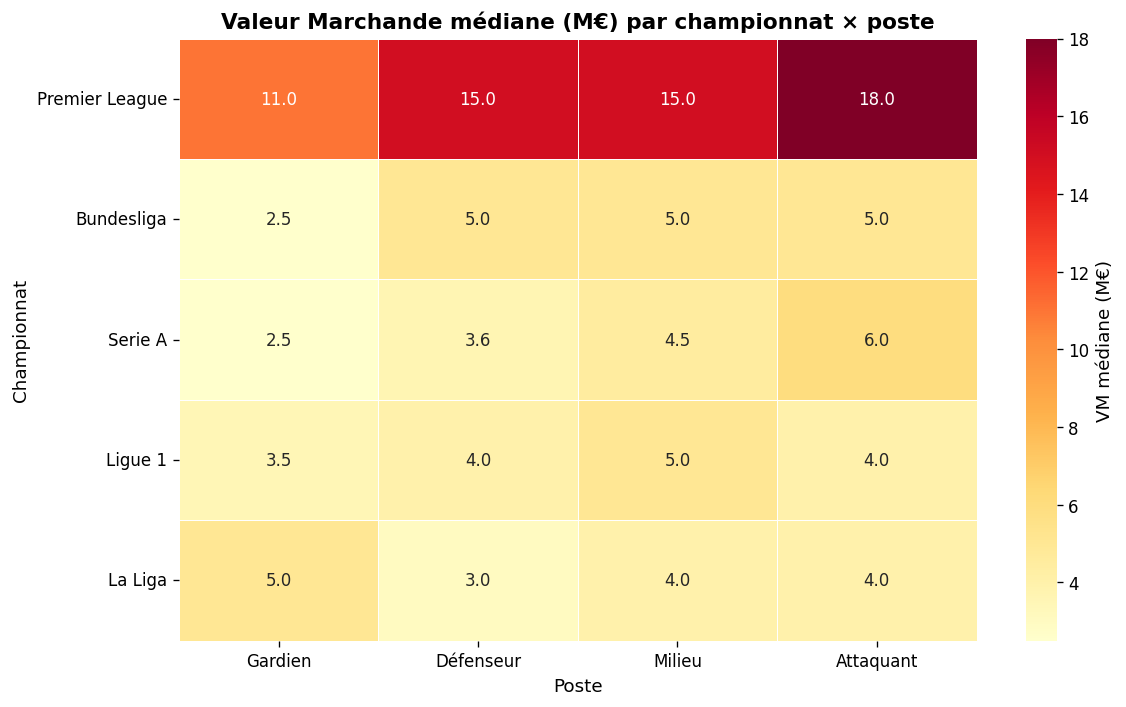

In [13]:
analyser_heatmap_league_poste(df_base, TARGET, dossier_sauvegarde=dossier_sauvegarde)

Analyse de la distribution par championnat



Violin plot sauvegardé sous : ..\outputs\eda\feature_engineered_violin_league.png


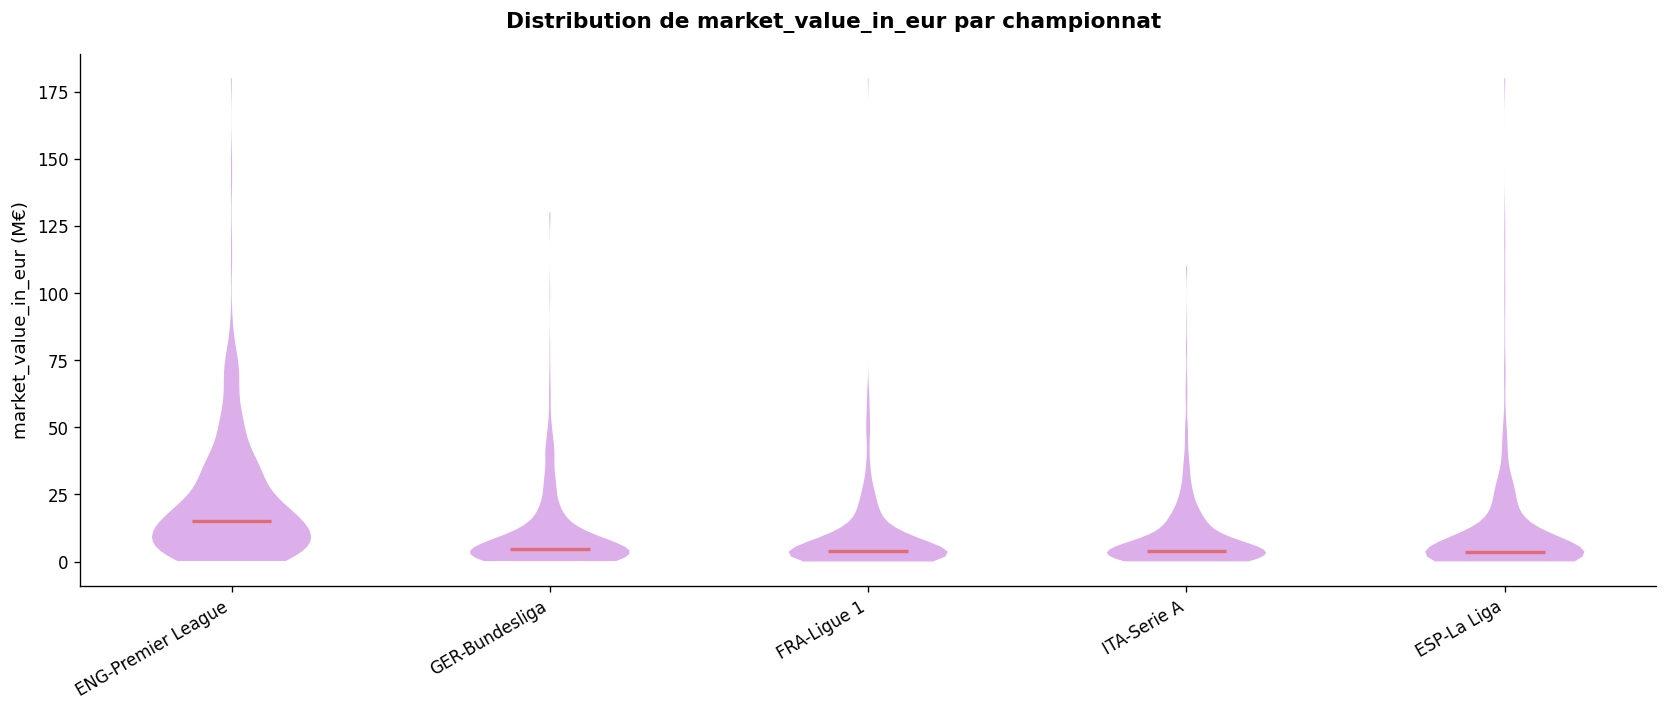

In [14]:
analyser_distribution_violin_league(df_base, TARGET, dossier_sauvegarde=dossier_sauvegarde, couleurs_dict=None)

Analyse des outliers et profils Spécifiques (cible : market_value_in_eur)

Joueurs avec market_value_in_eur ≥ 100M€ : 19 observations

Top 20 des joueurs les plus chers
             player position  market_value_in_eur  Performance_Gls        xg  Per 90 Minutes_G+A
    Jude Bellingham Midfield                180.0               19 12.974516                0.97
      Kylian Mbappé   Attack                180.0               27  2.055070                1.42
     Erling Haaland   Attack                180.0               27 31.653997                1.13
    Vinicius Júnior   Attack                180.0               15  3.188221                0.97
         Phil Foden Midfield                150.0               19 11.307983                0.85
        Bukayo Saka   Attack                140.0               16 16.807056                0.77
              Rodri Midfield                130.0                8  4.294270                0.38
      Jamal Musiala Midfield                130.0      

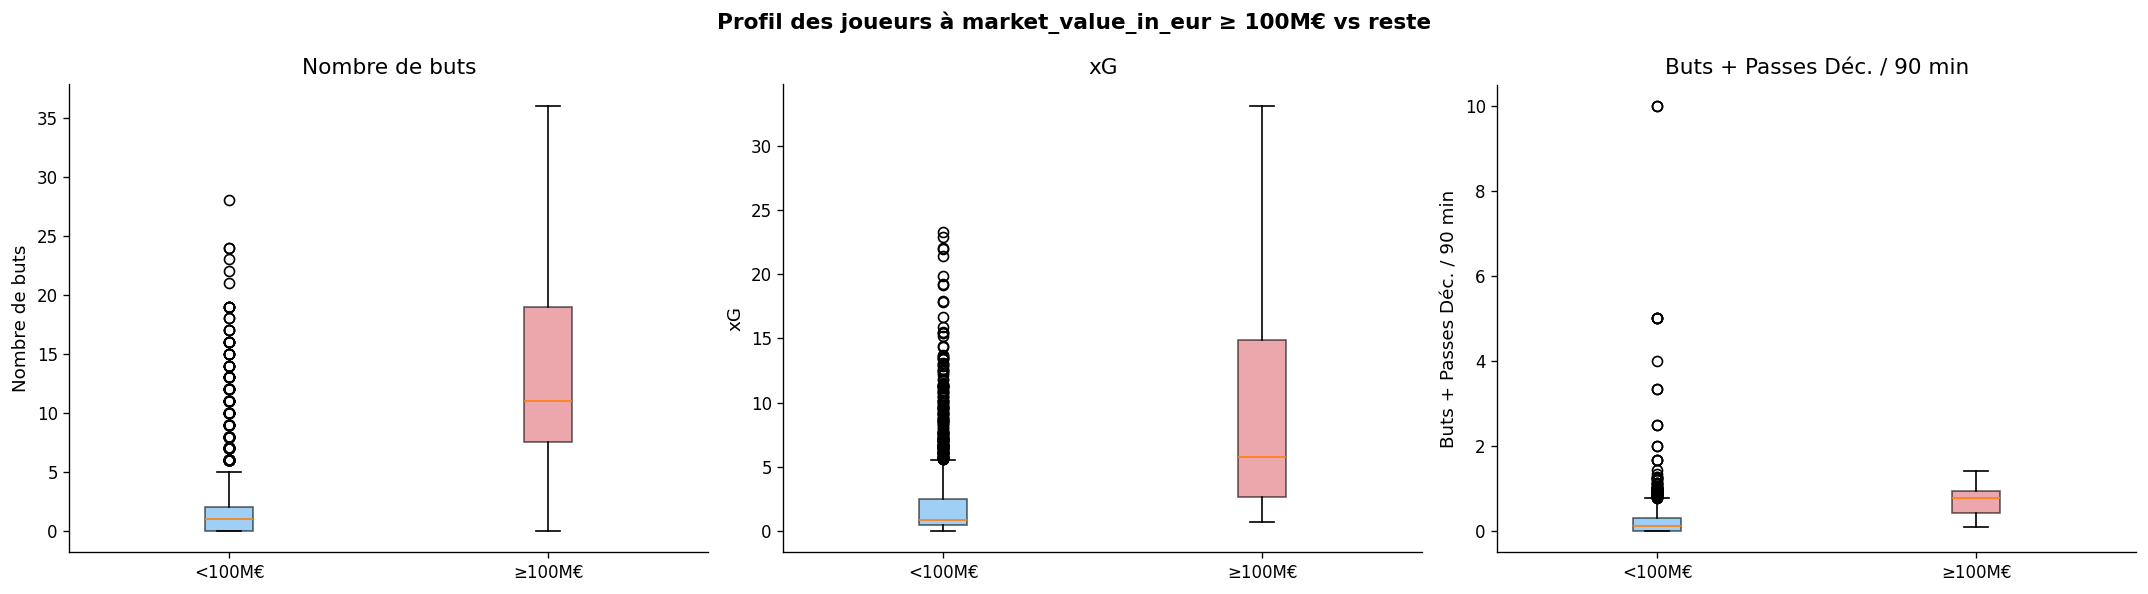

In [15]:
analyser_profil_outliers(df_base, TARGET, dossier_sauvegarde=dossier_sauvegarde, couleurs_dict=None)

In [16]:
verifier_coherence_jours_blessures(df_base)

Contrôle de cohérence : jours de blessures

Cohérence injury_days_total vs somme des composantes (2431/2431 lignes analysées) :
  Cohérents (diff = 0)           : 2,324
  Diff ≤ 1 jour                  : 2,324
  Diff > 1 jour (anomalie)       : 107
  Diff max                       : 874 jours

Des incohérences ont été détectées. Cela peut provenir de blessures
 qui se chevauchent dans le temps ou de catégories non répertoriées ici.


Analyse de l'évolution temporelle par Saison (cible : market_value_in_eur)

Évolution VM par saison :
             Médiane (M€)  Moyenne (M€)  Nb joueurs
season_year                                        
2023                  5.0     12.006643        2431

Graphique sauvegardé sous : ..\outputs\eda\evolution_temporelle.png


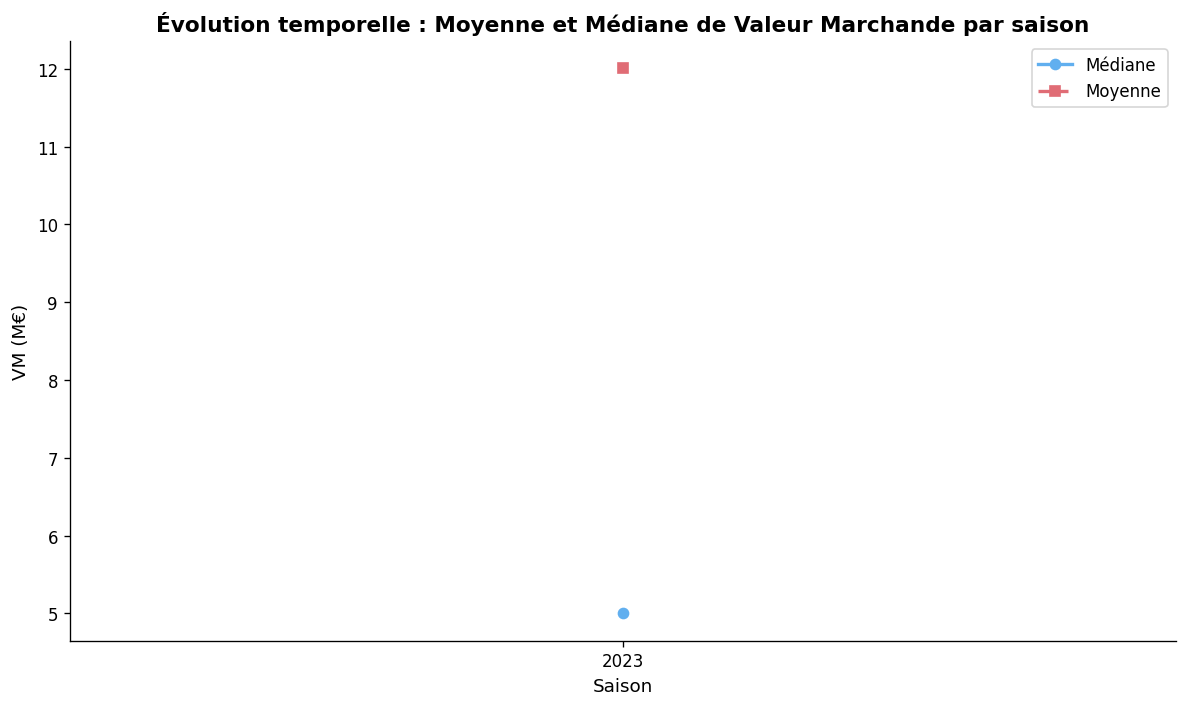

,Médiane (M€),Moyenne (M€),Nb joueurs
season_year,,,
2023,5.0,12.006643,2431


In [17]:
analyser_evolution_temporelle_saison(df_base, TARGET, dossier_sauvegarde=dossier_sauvegarde, couleurs_dict=None)

Démarrage de l'analyse du cycle de vie financier...
2431 observations valides trouvées pour l'analyse graphique.


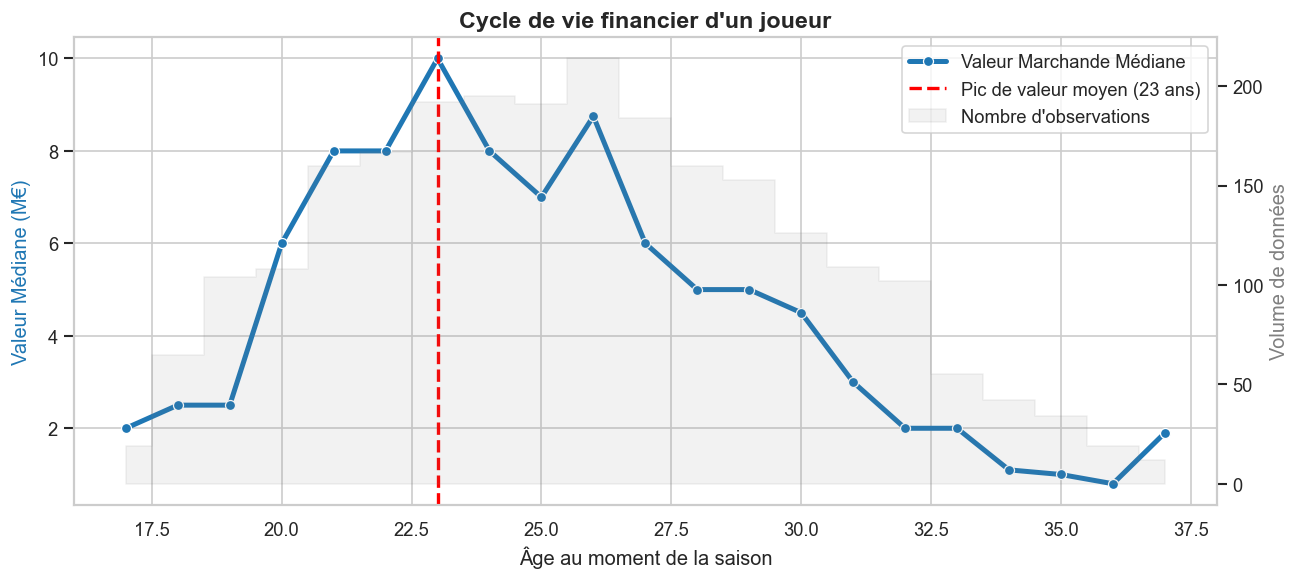


Graphique généré avec succès.


In [18]:
# Application de la fonction
df_base = analyser_cycle_vie_financier(df_base)

Démarrage de l'analyse de distribution des prix...
5 championnats détectés et ordonnés pour l'affichage.


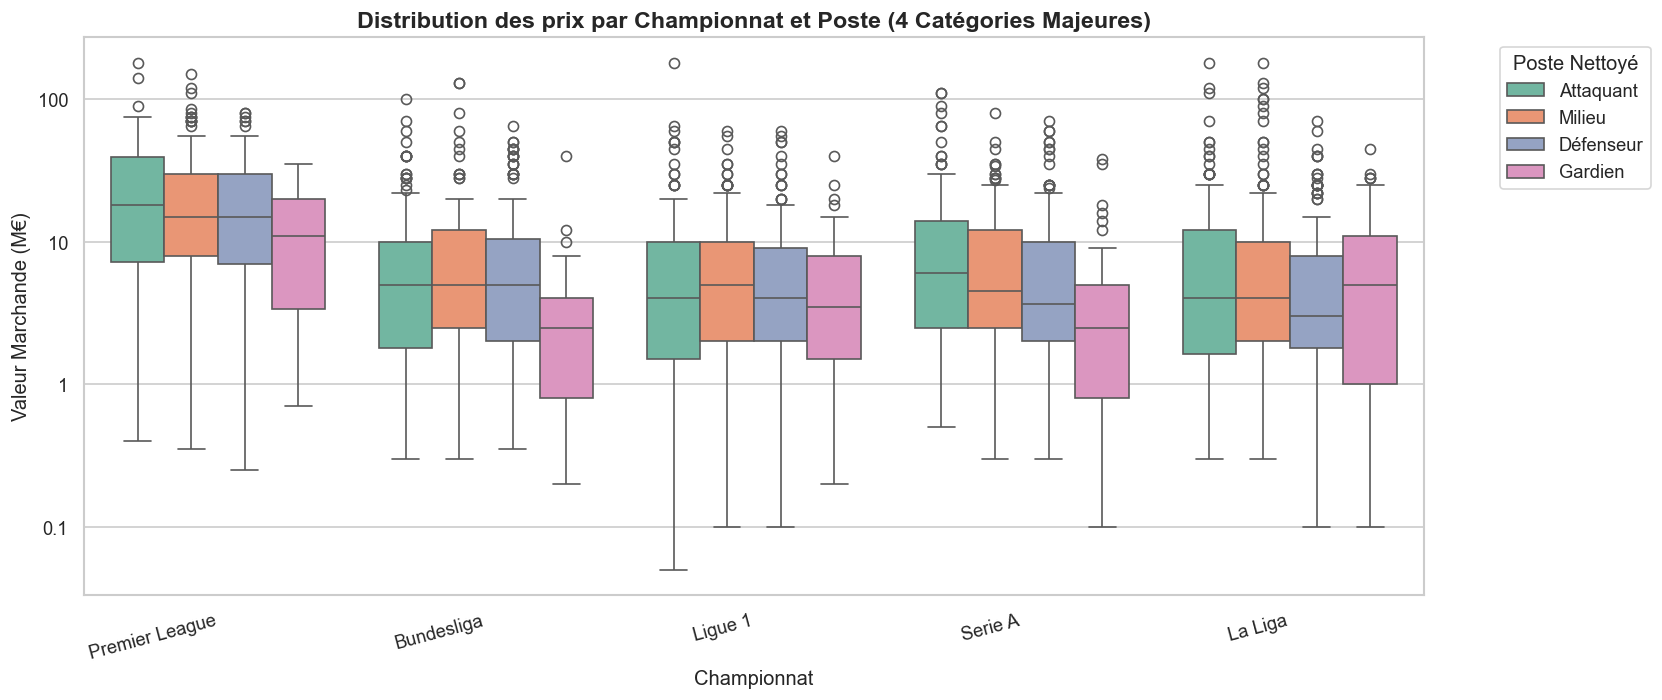


Boxplot généré avec succès.


In [19]:
analyser_distribution_prix_ligue_poste(df_base)

In [20]:
# On détecte les colinéarités
colinearites = detecter_top_colinearites(df_base, top_n=30)

# On affiche le tableau
display(colinearites)

Extraction du Top 30 des colinéarités (hors variables normalisées)...


,Variable_A,Variable_B,Correlation
0,Playing Time_90s,Playing Time_Starts,0.993
1,sub_position_Goalkeeper,pos_GK,0.988
2,Performance_G-PK,Performance_Gls,0.978
3,Performance_Saves,Performance_GA,0.976
4,pos_GK,Performance_Save%,0.971
5,injury_genou_nb_m,injury_genou_nb_d,0.967
6,Performance_PKatt,Performance_PK,0.966
7,injury_dos_bassin_nb_m,injury_dos_bassin_nb_d,0.966
8,injury_trauma_severe_nb_m,injury_trauma_severe_nb_d,0.965
9,sub_position_Goalkeeper,Performance_Save%,0.961


In [21]:
df_base

,player,team,nation,age,Playing Time_MP,Playing Time_Starts,Playing Time_90s,Performance_Gls,Performance_Ast,Performance_G-PK,...,Performance_CS%_nor,Standard_Sh_nor,Standard_SoT_nor,Standard_SoT%_nor,Standard_G/Sh_nor,Standard_G/SoT_nor,Team Success_PPM_nor,xg_nor,xa_nor,xg_buildup_nor
0,Aaron Cresswell,West Ham United,ENG,34,11,4,4.8,0,0,0,...,0.000,0.000000,0.000000,0.0000,0.00,0.000,0.173913,0.018839,NaN,NaN
1,Aaron Hickey,Brentford,SCO,21,9,9,7.9,0,0,0,...,0.000,0.035897,0.010989,0.1429,0.00,0.000,0.193043,0.005906,0.002908,0.040458
2,Aaron Malouda,Lille,FRA,18,1,0,0.0,0,0,0,...,0.000,0.000000,0.000000,0.0000,0.00,0.000,0.521739,0.000000,0.000000,0.000000
3,Aaron Ramsdale,Arsenal,ENG,25,6,6,6.0,0,0,0,...,0.333,0.000000,0.000000,0.0000,0.00,0.000,0.464348,0.000000,0.000000,0.031706
4,Aaron Seydel,Darmstadt 98,GER,27,16,5,6.9,1,0,1,...,0.000,0.071795,0.065934,0.4286,0.07,0.085,0.086957,0.105388,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2426,Ørjan Nyland,Sevilla,NOR,33,24,24,24.0,0,0,0,...,0.208,0.000000,0.000000,0.0000,0.00,0.000,0.240000,0.000000,0.020583,0.207124
2427,Đorđe Petrović,Chelsea,SRB,24,23,22,22.1,0,0,0,...,0.182,0.000000,0.000000,0.0000,0.00,0.000,0.332174,0.000000,NaN,NaN
2428,İlkay Gündoğan,Barcelona,GER,33,36,33,33.3,5,9,4,...,0.000,0.220513,0.186813,0.3953,0.12,0.145,0.380870,0.032207,NaN,NaN
2429,Łukasz Fabiański,West Ham United,POL,38,10,7,8.0,0,0,0,...,0.143,0.000000,0.000000,0.0000,0.00,0.000,0.191304,0.000000,NaN,NaN


Analyse des variables les plus explicatives pour : market_value_in_eur
Filtrage appliqué : Analyse exclusive des Gardiens de but.


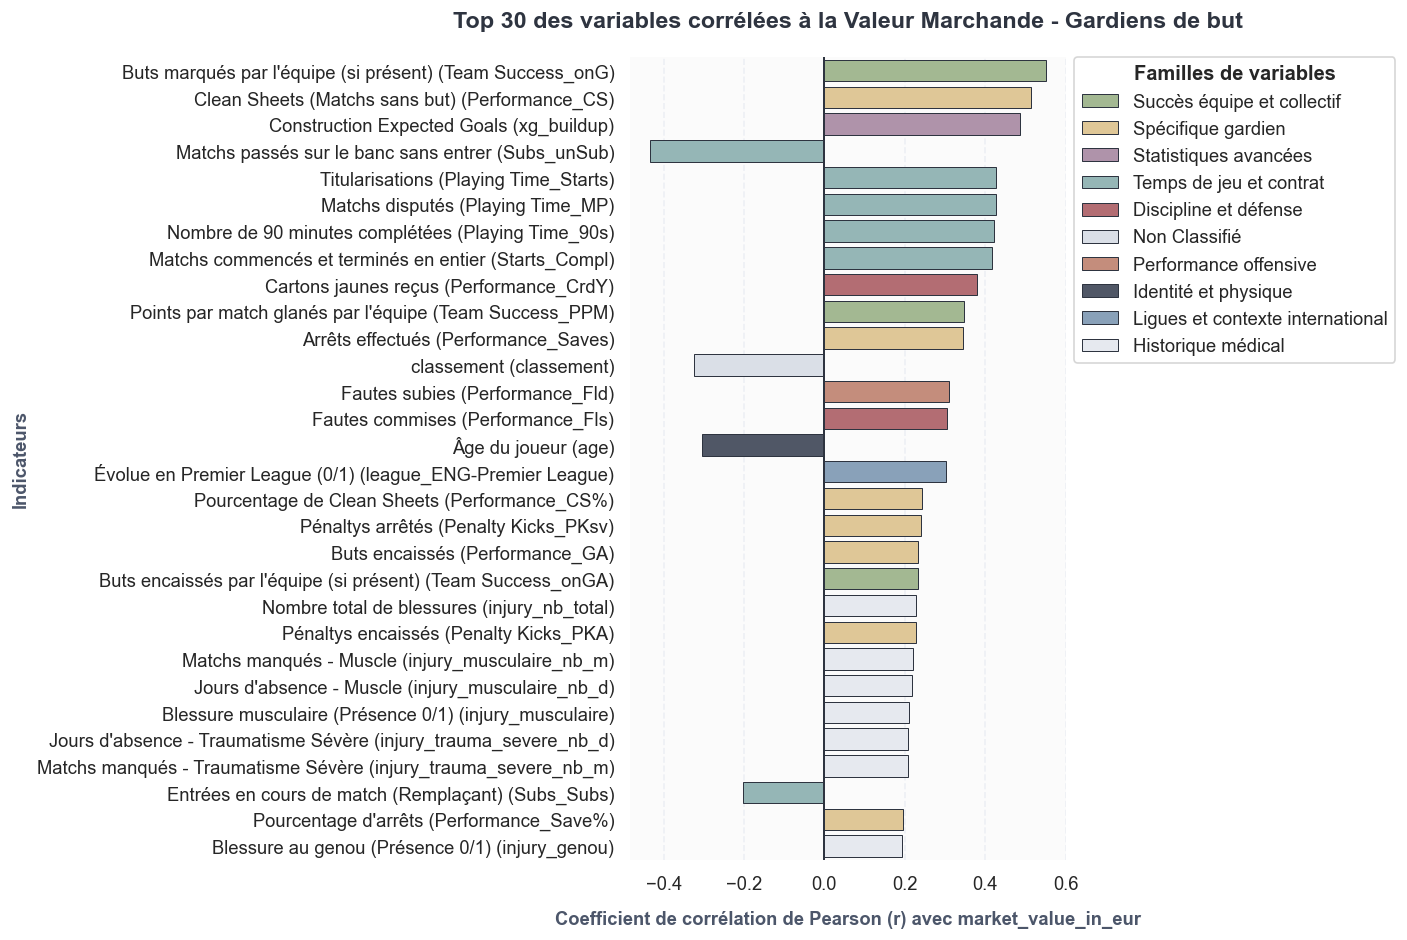

,Variable,Description,Famille,Corr_Cible_Brute
0,Team Success_onG,Buts marqués par l'équipe (si présent) (Team S...,Succès équipe et collectif,0.551
1,Performance_CS,Clean Sheets (Matchs sans but) (Performance_CS),Spécifique gardien,0.515
2,xg_buildup,Construction Expected Goals (xg_buildup),Statistiques avancées,0.487
3,Subs_unSub,Matchs passés sur le banc sans entrer (Subs_un...,Temps de jeu et contrat,-0.434
4,Playing Time_Starts,Titularisations (Playing Time_Starts),Temps de jeu et contrat,0.428
5,Playing Time_MP,Matchs disputés (Playing Time_MP),Temps de jeu et contrat,0.426
6,Playing Time_90s,Nombre de 90 minutes complétées (Playing Time_...,Temps de jeu et contrat,0.421
7,Starts_Compl,Matchs commencés et terminés en entier (Starts...,Temps de jeu et contrat,0.416
8,Performance_CrdY,Cartons jaunes reçus (Performance_CrdY),Discipline et défense,0.380
9,Team Success_PPM,Points par match glanés par l'équipe (Team Suc...,Succès équipe et collectif,0.347


In [22]:
# On applique la fonction
tableau_importance = analyser_variables_les_plus_explicatives(df_base,
                                                              target_col=TARGET,
                                                              top_n=30,
                                                              afficher_nom_technique=True,
                                                              uniquement_gardiens=True)

# On affiche le tableau propre sous le graphique
display(tableau_importance)

In [23]:
# Filtrez sur les gardiens uniquement avant de calculer la corrélation
df_gardiens = df_base[df_base["pos_GK"] == 1]

# Calculez la corrélation pearson
print(df_gardiens[["Performance_GA", "market_value_in_eur"]].corr())

                     Performance_GA  market_value_in_eur
Performance_GA             1.000000             0.233775
market_value_in_eur        0.233775             1.000000


In [24]:
# Corrélation brute
print(df_gardiens[["Performance_GA", "market_value_in_eur"]].corr())

# Corrélation entre les buts encaissés et la VM, mais à temps de jeu strictement égal
p_corr = pg.partial_corr(
    data=df_gardiens,
    x="Performance_GA",
    y="market_value_in_eur",
    covar="Playing Time_90s",
)

print(p_corr)

                     Performance_GA  market_value_in_eur
Performance_GA             1.000000             0.233775
market_value_in_eur        0.233775             1.000000
           n         r            CI95     p_val
pearson  180 -0.349969  [-0.47, -0.21]  0.000002


La corrélation à temps de jeu égal est bien négative : $-0.479881$, une valeur plus élevée que la corrélation de la colonne Performance_GA90 ($-0,20$). 

C'est parce que la variable Performance_GA90 (buts/90min) souffre d'un autre biais : le biais des petits échantillons.
Exemple : Un gardien remplaçant très faible entre en jeu, joue 10 minutes et prend 2 buts. Son ratio par 90 minutes explose (il monte à $18,0$ buts par match !). 

Ce genre de valeur extrême (outlier) vient "bruiter" et affaiblir votre corrélation Pearson classique sur la colonne des ratios.
La corrélation partielle, elle, étudie les volumes bruts sous contrôle mathématique. Elle contourne ce bruit des ratios extrêmes sur des petits temps de jeu, ce qui donne la vraie mesure de l'impact négatif des buts encaissés sur la valeur marchande d'un gardien.